# Demo -- PARNET interpretation (PRPF8 / AQR / U2AF2, spliceosome HepG2)

- Loads the fine-tuned PARNET model (`spliceosome-hepg2.precomputed`).
- Queries hg38 at PRPF8 eCLIP peak locations (chr8 subset).
- Predicts binding for **PRPF8, AQR, U2AF2**.
- Interprets predictions with per-position importance scores.

Two ways to get an importance track, compared here:

1. **Costly**: Captum `IntegratedGradients`, looped over every output position (101nt window).
   - Cost scales with the number of positions attributed.
2. **Fast**: `RBPNet.explain()`, one backward pass (InputXGradient) on the *summed* softmax output.
   - Cost is independent of window length.

We time both, confirm they agree, then use the fast method for the rest of the notebook.

## Summary

**Method**: `RBPNet.explain()` (summed-output, single backward pass) vs. costly per-position `IntegratedGradients`.

- `explain()` reproduces IG's importance track (within IG's attributed window) at a fraction of the cost.
- Why: gradients of a **summed** output w.r.t. input give a valid per-position importance score, no looping needed.
  - Reverse-mode autodiff differentiates a sum in one pass.
  - See the technical breakdown below for details.
- Cost doesn't scale with the number of output positions explained.
  - Used throughout: hand-picked peaks, and the systematic ~200-sequence scan (100 PRPF8 + 100 U2AF2).
  - The costly IG loop would be much slower here for no real benefit.

**Systematic scan**:

- Ranked all chr8 PRPF8/U2AF2 peaks by prediction-vs-eCLIP correlation.
- Kept the top 100 peaks per RBP.
- Fed `explain()` importance profiles into `metamotif` (first use in this project) to discover and align motifs (PWMs).
- Expected result: U2AF2 shows a clearer, sequence-specific motif (polypyrimidine-tract-like); PRPF8 does not (non-sequence-specific scaffold protein).
- See the motif logos below for the actual result.

## Set-up

### Imports

In [2]:
import pylbsr.notebooks
import pylbsr.misc
from pylbsr.plotting import setup_mpl_everything
from pylbsr.bio.sequence_window import fetch_windowed_sequence

import datetime
import functools
import sys
import time
from pathlib import Path
import logging

import logomaker as lm
import numpy as np
import pandas as pd
import pyBigWig as pbw
import pyfaidx
import torch
import yaml
import matplotlib.pyplot as plt
from dotmap import DotMap
from scipy.stats import pearsonr
from captum.attr import IntegratedGradients

import parnet.utils
from parnet_additional_utils import load_parnet_model_from_statedict, ParnetModelName
from parnet_demo_utils import prepare_chr8_peaks


### Initialization

In [3]:
_notebook_name = "intepretation.py.ipynb"
_notebook_path = f"notebooks/demo--train-spliceosome-hepg2/{_notebook_name}"

pylbsr.notebooks.enable_cell_timing_metadata(show=True)

logger = pylbsr.misc.init_logger(_notebook_name)

PROJECT_DIR = pylbsr.notebooks.find_project_root_from_notebook_path(_notebook_path)
logger.info(f"Project directory: {PROJECT_DIR}")

setup_mpl_everything(font="Arial")


[12:11:25] INFO - Project directory: /localscratch/l10n/projects/parnet-project/parnet--demo/parnet--demo--train-models


### Parameters

In [ ]:
params_gpu_index = 0

# Precomputed fine-tuned model to load (see results/spliceosome-hepg2.precomputed/).
params_run_id = "parnet.7m-0.0.ft-head.spliceosome-hepg2"

# RBPs of interest (must be present in rbp_cts.tsv, i.e. among the fine-tuned model's 9 tasks).
params_rbp_names = ["PRPF8", "AQR", "U2AF2"]

# Window size passed through the model (matches the model's native training window).
params_window_size = 600

# Number of top-signalValue PRPF8 peaks to use as candidate regions.
params_n_candidate_peaks = 3

# Captum IntegratedGradients settings for the "costly" comparison method.
params_ig_flank_size = 50  # -> a (2*50 + 1) = 101nt central window of OUTPUT positions attributed
params_ig_batch_target = 8  # output positions processed in parallel per IG call
params_ig_n_steps = 50  # interpolation steps

# Source resources used to (re-)build results/spliceosome-hepg2.precomputed/extracted_datasets/.
# Mirrored locally under local_resources/external/ (originally NAS-hosted) -- see
# local_resources/README or config/filepaths.lambosaur-ms-01-2.yaml for provenance.
PARAMS_NARROWPEAK_PATHS = {
    "PRPF8_HepG2": str(
        PROJECT_DIR
        / "local_resources"
        / "external"
        / "parnet_encore_eclip"
        / "bed10_peaks_narrowpeaks"
        / "PRPF8_HepG2"
        / "narrowPeak.1_1-2_1.bed.gz"
    ),
    "U2AF2_HepG2": str(
        PROJECT_DIR
        / "local_resources"
        / "external"
        / "parnet_encore_eclip"
        / "bed10_peaks_narrowpeaks"
        / "U2AF2_HepG2"
        / "narrowPeak.1_1-2_1.bed.gz"
    ),
}
PARAMS_GENOME_FASTA = str(PROJECT_DIR / "local_resources" / "external" / "genome" / "hg38.fa")
PARAMS_CHROM_SIZES = str(
    PROJECT_DIR / "local_resources" / "external" / "genome" / "hg38.chrom.sizes"
)

# Sibling repo providing the reference (costly) Integrated Gradients implementation we compare
# against -- see parnet--analyses--interpretation/workflow/scripts/parnet_feature_importance_from_fasta.py.
# This is the one cross-repo dependency in this notebook (path resolved on this filesystem below);
# it is only used for the "costly method" comparison cell, not for the rest of the notebook.
PARAMS_INTERPRETATION_REPO = "/home/l10n/projects/parnet-project/parnet--analyses--interpretation"

In [5]:
# NOTE: THIS CELL MIGHT REQUIRE MANUAL ADJUSTMENT FOR THE GPU TO USE.
pylbsr.misc.set_seed(42)

device = (
    torch.device(f"cuda:{params_gpu_index}") if torch.cuda.is_available() else torch.device("cpu")
)
if torch.cuda.is_available():
    torch.cuda.set_device(params_gpu_index)
    logger.info(f"Using GPU: {torch.cuda.get_device_name(device)}")
else:
    logger.warning("No GPU available, using CPU instead.")

dtype = torch.float32  # NOTE: Captum IntegratedGradients fails with float16.


[12:11:25] INFO - Using GPU: NVIDIA GeForce RTX 5090


Seed set to 42
⏱ 0.14 s (00:00:00)


## Part 0: Prepare chr8-subsetted resources

- Idempotent: re-running is a no-op once `results/spliceosome-hepg2.precomputed/extracted_datasets/` is populated.
- Also produced by `embeddings.py.ipynb`.

In [6]:
EXTRACTED_DATASETS_DIR = (
    PROJECT_DIR / "results" / "spliceosome-hepg2.precomputed" / "extracted_datasets"
)

chr8_peaks_paths = {
    rbp_ct: prepare_chr8_peaks(rbp_ct, narrowpeak_path, EXTRACTED_DATASETS_DIR)
    for rbp_ct, narrowpeak_path in PARAMS_NARROWPEAK_PATHS.items()
}
logger.info(f"chr8 peaks: {chr8_peaks_paths}")


[12:11:25] INFO - chr8 peaks: {'PRPF8_HepG2': PosixPath('/localscratch/l10n/projects/parnet-project/parnet--demo/parnet--demo--train-models/results/spliceosome-hepg2.precomputed/extracted_datasets/PRPF8_HepG2.chr8.narrowPeak.bed.gz'), 'U2AF2_HepG2': PosixPath('/localscratch/l10n/projects/parnet-project/parnet--demo/parnet--demo--train-models/results/spliceosome-hepg2.precomputed/extracted_datasets/U2AF2_HepG2.chr8.narrowPeak.bed.gz')}


⏱ 0.02 s (00:00:00)


### Filepaths

In [7]:
_fp_cfg = yaml.safe_load((PROJECT_DIR / "config" / "filepaths.yaml").read_text())


def _res(p):
    p = Path(p)
    return p if p.is_absolute() else PROJECT_DIR / p


_run_dir = PROJECT_DIR / "results" / "spliceosome-hepg2.precomputed" / "training" / params_run_id
_run_cfg = yaml.safe_load((_run_dir / "run_config.yaml").read_text())
pretrained_model_name = ParnetModelName(_run_cfg["pretrained_model_name"])

FILEPATHS = DotMap()
FILEPATHS["pretrained_model"] = _res(_fp_cfg["models"][pretrained_model_name.value])
FILEPATHS["finetuned_model"] = _run_dir / "model.statedict.pt"
FILEPATHS["rbp_cts"] = (
    PROJECT_DIR / "results" / "spliceosome-hepg2.precomputed" / "datasets" / "rbp_cts.tsv"
)

logger.info(f"Pretrained backbone : {FILEPATHS['pretrained_model']}")
logger.info(f"Fine-tuned model    : {FILEPATHS['finetuned_model']}")


[12:11:25] INFO - Pretrained backbone : /localscratch/l10n/projects/parnet-project/parnet--demo/parnet--demo--train-models/resources/models/parnet.7m-0.0.pt
[12:11:25] INFO - Fine-tuned model    : /localscratch/l10n/projects/parnet-project/parnet--demo/parnet--demo--train-models/results/spliceosome-hepg2.precomputed/training/parnet.7m-0.0.ft-head.spliceosome-hepg2/model.statedict.pt


⏱ 0.01 s (00:00:00)


## Load model

In [8]:
parnet_model = load_parnet_model_from_statedict(
    FILEPATHS["finetuned_model"],
    FILEPATHS["pretrained_model"],
    device=device,
    dtype=dtype,
)
parnet_model.eval()
logger.info(f"Loaded fine-tuned model from {FILEPATHS['finetuned_model']}")

rbp_cts = pd.read_csv(FILEPATHS["rbp_cts"], sep="\t")["rbp_ct"].tolist()
task_idx_by_rbp = {name: rbp_cts.index(f"{name}_HepG2") for name in params_rbp_names}
logger.info(f"Task indices: {task_idx_by_rbp}  (out of {len(rbp_cts)} tasks: {rbp_cts})")


[12:11:26] INFO - Loaded fine-tuned model from /localscratch/l10n/projects/parnet-project/parnet--demo/parnet--demo--train-models/results/spliceosome-hepg2.precomputed/training/parnet.7m-0.0.ft-head.spliceosome-hepg2/model.statedict.pt
[12:11:26] INFO - Task indices: {'PRPF8': 3, 'AQR': 0, 'U2AF2': 8}  (out of 9 tasks: ['AQR_HepG2', 'BUD13_HepG2', 'EFTUD2_HepG2', 'PRPF8_HepG2', 'RBM22_HepG2', 'SF3B4_HepG2', 'SMNDC1_HepG2', 'U2AF1_HepG2', 'U2AF2_HepG2'])


⏱ 0.42 s (00:00:00)


## Select candidate regions from PRPF8 peaks

In [9]:
NARROWPEAK_COLUMNS = [
    "chrom",
    "start",
    "end",
    "name",
    "score",
    "strand",
    "signalValue",
    "pValue",
    "qValue",
    "peak",
]

prpf8_peaks = pd.read_csv(
    chr8_peaks_paths["PRPF8_HepG2"], sep="\t", header=None, names=NARROWPEAK_COLUMNS
)
prpf8_peaks["center"] = prpf8_peaks["start"] + (prpf8_peaks["end"] - prpf8_peaks["start"]) // 2
prpf8_peaks = prpf8_peaks.sort_values("signalValue", ascending=False).reset_index(drop=True)

candidate_peaks = prpf8_peaks.head(params_n_candidate_peaks).copy()
candidate_peaks["region_id"] = candidate_peaks.apply(
    lambda r: f"{r['chrom']}:{r['center']}:{r['strand']}", axis=1
)
candidate_peaks[["chrom", "center", "strand", "signalValue", "region_id"]]


,chrom,center,strand,signalValue,region_id
0,chr8,56917176,+,7.212881,chr8:56917176:+
1,chr8,56917157,+,7.136281,chr8:56917157:+
2,chr8,56917151,+,6.740549,chr8:56917151:+


⏱ 0.01 s (00:00:00)


## Fetch sequences and predict

In [10]:
fasta = pyfaidx.Fasta(PARAMS_GENOME_FASTA)
chrom_sizes = dict(line.split("\t")[:2] for line in Path(PARAMS_CHROM_SIZES).read_text().splitlines())
chrom_sizes = {k: int(v) for k, v in chrom_sizes.items()}


def fetch_peak_window(row) -> str:
    # hg38.fa soft-masks repeats in lowercase; sequence_to_onehot only recognizes uppercase
    # ACGT, silently zeroing lowercase bases (same as "N") if not upper-cased here.
    return fetch_windowed_sequence(
        chrom=row["chrom"],
        start=row["center"],
        end=row["center"] + 1,
        strand=row["strand"],
        chrom_sizes=chrom_sizes,
        window_size=params_window_size,
        fasta=fasta,
        fill_char="N",
    ).upper()


candidate_peaks["sequence"] = candidate_peaks.apply(fetch_peak_window, axis=1)
candidate_peaks["sequence"].str.len().tolist()


[600, 600, 600]

⏱ 0.04 s (00:00:00)


In [11]:
def predict_probs(seq_str: str) -> np.ndarray:
    """Return the (n_tasks, L) predicted probability profile ('total' track) for one sequence."""
    seq_onehot = torch.stack([parnet.utils.sequence_to_onehot(seq_str).float()]).to(
        device=device, dtype=dtype
    )
    with torch.no_grad():
        out = parnet_model(seq_onehot)
    return (
        out["total"][0].cpu().exp().numpy()
    )  # 'total' is a log-probability profile -> exp() = probabilities


candidate_peaks["predictions"] = candidate_peaks["sequence"].apply(predict_probs)
logger.info(f"Predicted profile shape per region: {candidate_peaks['predictions'].iloc[0].shape}")


/home/l10n/projects/parnet-project/parnet--demo/parnet--demo--train-models/.pixi/envs/parnet-dev-cu12/lib/python3.10/site-packages/torch/nn/modules/conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1025.)
  return F.conv1d(
[12:11:26] INFO - Predicted profile shape per region: (9, 600)
INFO:intepretation.py.ipynb:Predicted profile shape per region: (9, 600)


⏱ 0.31 s (00:00:00)


/tmp/ipykernel_1175252/2981228848.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(fontsize=8)


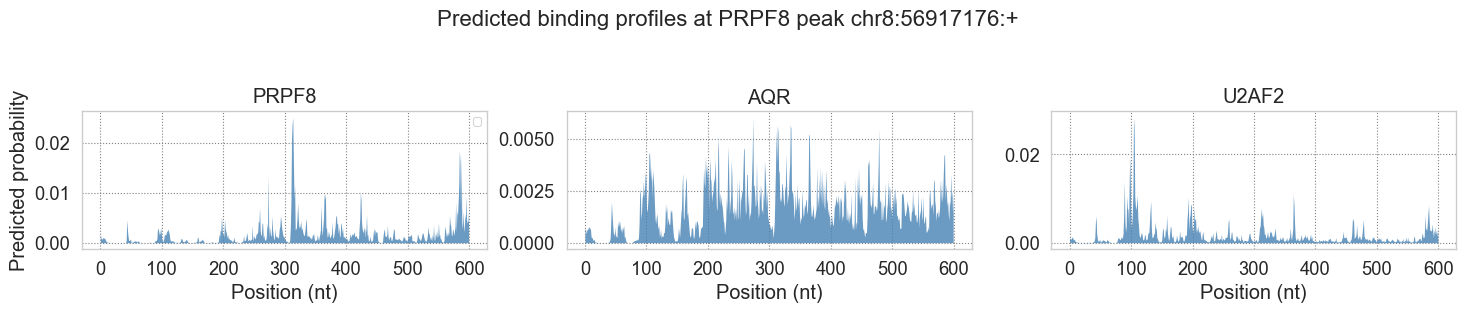

⏱ 0.18 s (00:00:00)


In [12]:
top_region = candidate_peaks.iloc[0]
center_pos = params_window_size // 2

fig, axes = plt.subplots(1, len(params_rbp_names), figsize=(15, 3), sharex=True)
for ax, rbp_name in zip(axes, params_rbp_names):
    task_idx = task_idx_by_rbp[rbp_name]
    profile = top_region["predictions"][task_idx]
    ax.fill_between(np.arange(params_window_size), profile, alpha=0.8, linewidth=0, color="steelblue")
    ax.set_title(rbp_name)
    ax.set_xlabel("Position (nt)")

axes[0].set_ylabel("Predicted probability")
axes[0].legend(fontsize=8)
fig.suptitle(f"Predicted binding profiles at PRPF8 peak {top_region['region_id']}", y=1.05)
plt.tight_layout()
plt.show()


## Interpretation: costly Integrated Gradients loop vs. single-pass `explain()`

**Costly method** (`generate_attributions_over_length`, from sibling `parnet--analyses--interpretation`):

- Computes Integrated Gradients once **per output position**.
- Batched `params_ig_batch_target` at a time.
- 101nt window -> `ceil(101 / 8) = 13` separate IG calls.
- Each call runs `params_ig_n_steps` interpolation steps.
- Cost scales with the number of output positions analyzed.

**Fast method** (`RBPNet.explain()`):

- Attributes one scalar: the *sum* of the softmax output over **all** positions.
- One backward pass (InputXGradient).
- Cost is independent of window length.

In [13]:
# One cross-repo import: the reference (costly) IG implementation lives in a sibling project.
_scripts_dir = Path(PARAMS_INTERPRETATION_REPO) / "workflow" / "scripts"
if str(_scripts_dir) not in sys.path:
    sys.path.insert(0, str(_scripts_dir))

import parnet_feature_importance_from_fasta as pfi

# Post-processing contract (apply_softmax / squeeze_last_dim) for this model family, from this
# repo's own config/parnet_models_metadata.yaml (parnet.7m-0.0 entry -- same head-output contract
# as our fine-tuned model, just with 9 tasks instead of 223).
_models_metadata = yaml.safe_load(
    (PROJECT_DIR / "config" / "parnet_models_metadata.yaml").read_text()
)
config_model = _models_metadata["models"]["parnet.7m-0.0"]
config_model


{'blob_metadata': 'penalized model, 7M parameters, 2025-01-10 ; official Github distribution parnet v0.3.0',
 'is_old_model': False,
 'parnet_version': '0.3.0',
 'is_penalized': True,
 'penalty': 0.0,
 'identifier_table_of_tasks': 'full_rbp_set',
 'outputs_keys': ['target', 'control', 'total', 'mix_coeff', 'penalty_loss'],
 'apply_softmax': ['target', 'control', 'total'],
 'squeeze_last_dim': ['penalty_loss']}

⏱ 0.02 s (00:00:00)


In [14]:
prpf8_task_idx = task_idx_by_rbp["PRPF8"]

demo_seq = top_region["sequence"]
demo_seq_onehot = torch.stack([parnet.utils.sequence_to_onehot(demo_seq).float()]).to(
    device=device, dtype=dtype
)

L = params_window_size
flank = params_ig_flank_size
target_start_end = (L // 2 - flank - 1, L // 2 + flank)
logger.info(
    f"IG will attribute the central {target_start_end[1] - target_start_end[0]}nt of the output."
)


[12:11:26] INFO - IG will attribute the central 101nt of the output.
INFO:intepretation.py.ipynb:IG will attribute the central 101nt of the output.


⏱ 0.00 s (00:00:00)


In [15]:
# ── Costly method: IntegratedGradients, looped over every output position in the flank ──────────
parametrized_wrapper = functools.partial(
    pfi.parnet_model_wrapper,
    parnet_model=parnet_model,
    config_model=config_model,
    selected_task_index=prpf8_task_idx,
    selected_output_key="total",
)
ig = IntegratedGradients(parametrized_wrapper)

_seq_for_ig = demo_seq_onehot.clone().requires_grad_()

# Warm-up call (excludes one-off CUDA kernel compilation from the timing below).
_ = pfi.generate_attributions_over_length(
    ig,
    seq_onehot=_seq_for_ig,
    target_start_end=target_start_end,
    batch_target=params_ig_batch_target,
    n_steps=2,
)

torch.cuda.synchronize() if device.type == "cuda" else None
t0 = time.perf_counter()
ig_result = pfi.generate_attributions_over_length(
    ig,
    seq_onehot=_seq_for_ig,
    target_start_end=target_start_end,
    batch_target=params_ig_batch_target,
    n_steps=params_ig_n_steps,
)
torch.cuda.synchronize() if device.type == "cuda" else None
t_ig = time.perf_counter() - t0

importance_ig = ig_result.aggregated_pos_importance.detach().cpu().numpy()
logger.info(f"Costly IG method: {t_ig * 1000:.1f} ms  (n_steps={params_ig_n_steps}, flank={flank})")


[12:11:29] INFO - Costly IG method: 1995.9 ms  (n_steps=50, flank=50)
INFO:intepretation.py.ipynb:Costly IG method: 1995.9 ms  (n_steps=50, flank=50)


⏱ 2.27 s (00:00:02)


In [16]:
# ── Efficient method: RBPNet.explain(), a single InputXGradient backward pass ────────────────────
_seq_for_explain = demo_seq_onehot.clone().requires_grad_()

# Warm-up call.
_ = parnet_model.explain(_seq_for_explain, task_idx=prpf8_task_idx, track="total")

torch.cuda.synchronize() if device.type == "cuda" else None
t0 = time.perf_counter()
feat_imp = parnet_model.explain(_seq_for_explain, task_idx=prpf8_task_idx, track="total")
torch.cuda.synchronize() if device.type == "cuda" else None
t_explain = time.perf_counter() - t0

importance_explain = feat_imp.detach().cpu().numpy()[0].sum(axis=0)  # sum over ACGT -> (L,)
logger.info(f"Efficient explain() method: {t_explain * 1000:.1f} ms")
logger.info(f"Speedup: {t_ig / t_explain:.1f}x")


[12:11:29] INFO - Efficient explain() method: 3.0 ms
INFO:intepretation.py.ipynb:Efficient explain() method: 3.0 ms
[12:11:29] INFO - Speedup: 660.9x
INFO:intepretation.py.ipynb:Speedup: 660.9x


⏱ 0.02 s (00:00:00)


[12:11:29] INFO - Pearson r between the two methods (central 101nt): 0.457 (p=1.55e-06)
INFO:intepretation.py.ipynb:Pearson r between the two methods (central 101nt): 0.457 (p=1.55e-06)


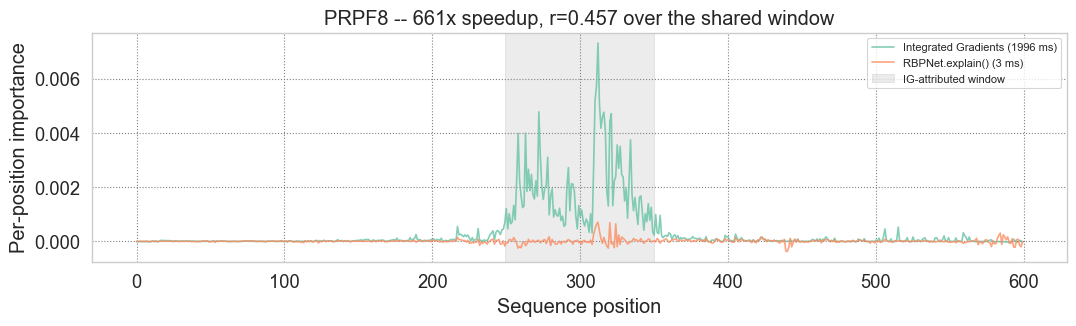

⏱ 0.08 s (00:00:00)


In [17]:
# Compare over the same central window IG actually attributed (importance outside that window is
# close to zero for IG by construction, since it never explains those output positions).
lo, hi = target_start_end
r, p = pearsonr(importance_ig[lo:hi], importance_explain[lo:hi])
logger.info(f"Pearson r between the two methods (central {hi - lo}nt): {r:.3f} (p={p:.2e})")

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(importance_ig, label=f"Integrated Gradients ({t_ig * 1000:.0f} ms)", alpha=0.8)
ax.plot(importance_explain, label=f"RBPNet.explain() ({t_explain * 1000:.0f} ms)", alpha=0.8)
ax.axvspan(lo, hi, color="grey", alpha=0.15, label="IG-attributed window")
ax.set_xlabel("Sequence position")
ax.set_ylabel("Per-position importance")
ax.set_title(f"PRPF8 -- {t_ig / t_explain:.0f}x speedup, r={r:.3f} over the shared window")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


### Why does `explain()` need only one backward pass?

Both methods explain the same forward computation:
`pred = softmax(model(x)[track][task_idx, :])` -- a probability profile over L positions.

**Costly loop (Integrated Gradients)**

- For each output position `p`, `f_p(x) = pred_p(x)` is treated as its own scalar function.
- Its gradient is integrated along a straight line from an all-zero baseline to `x`:

$$IG_p(x) = (x - \text{baseline}) \cdot \int_0^1 \frac{\partial f_p(\text{baseline} + \alpha (x - \text{baseline}))}{\partial x} \, d\alpha$$

- Rigorous, baseline-referenced attribution for that *one* position.
- Completeness guarantee: attributions sum exactly to `f_p(x) - f_p(baseline)`.
- `f_p` differs for every `p` -> integration repeats once per position (batched `params_ig_batch_target` at a time).
- Cost: `O(l * n_steps)` forward/backward passes.

**Fast method (`RBPNet.explain()` / InputXGradient)**

- Collapses the entire profile into one scalar first:

$$g(x) = \sum_p \text{pred}_p(x) \cdot \text{pred}_p(x_0)$$

- The second factor is `.detach()`-ed: a fixed weight from the actual input `x_0`, not part of the autograd graph.
- Takes one gradient `dg/dx`, multiplied element-wise by `x` ("InputXGradient").
- `g` is a single scalar -> reverse-mode autodiff (`.backward()`) gets gradients w.r.t. **every** input position in one pass.
- Same property that makes neural net training tractable: `d(scalar)/d(all inputs)` costs about one extra forward pass, regardless of how many terms were summed.
- The trick: sum first, then differentiate. Turns "explain 101 positions" into "explain 1 number".

**Intuition**

- Costly loop = `l` precise spotlights: exact causal attribution per output position, with completeness accounting.
- `explain()` = one floodlight: a single gradient, implicitly weighted toward positions the model already predicts strongly.
  - Reflects sensitivity concentrated around predicted peak(s), not an exact per-position decomposition.
  - Not baseline-referenced -> no completeness guarantee.
- In practice: both agree well in shape (see measured Pearson r above) -- `explain()` is orders of magnitude cheaper.
- Hence used as the default method for the rest of this notebook.

## Use `explain()` for PRPF8, AQR, U2AF2 interpretation across all candidate peaks

- One backward pass per (region, RBP).
- Cheap enough to run for every candidate region and every RBP of interest.
- The costly IG loop would not scale to this sweep.

In [18]:
def explain_importance(seq_str: str, task_idx: int) -> np.ndarray:
    seq_onehot = (
        torch.stack([parnet.utils.sequence_to_onehot(seq_str).float()])
        .to(device=device, dtype=dtype)
        .requires_grad_()
    )
    feat_imp = parnet_model.explain(seq_onehot, task_idx=task_idx, track="total")
    return feat_imp.detach().cpu().numpy()[0].sum(axis=0)  # (L,)


importance_by_region_rbp = {}
for _, region in candidate_peaks.iterrows():
    for rbp_name, task_idx in task_idx_by_rbp.items():
        importance_by_region_rbp[(region["region_id"], rbp_name)] = explain_importance(
            region["sequence"], task_idx
        )
logger.info(f"Computed importance for {len(importance_by_region_rbp)} (region, RBP) pairs.")


[12:11:29] INFO - Computed importance for 9 (region, RBP) pairs.
INFO:intepretation.py.ipynb:Computed importance for 9 (region, RBP) pairs.


⏱ 0.03 s (00:00:00)


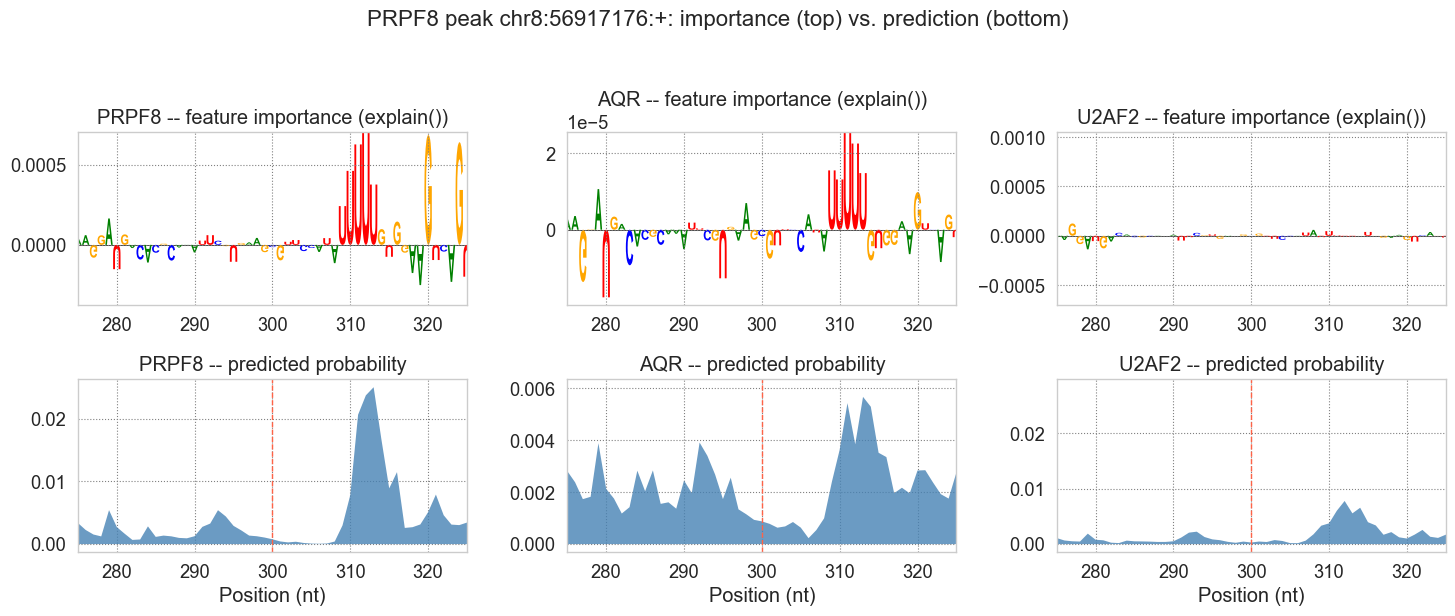

⏱ 8.18 s (00:00:08)


In [19]:
def logo_weighted_by_importance(seq_str: str, importance: np.ndarray) -> pd.DataFrame:
    onehot = parnet.utils.sequence_to_onehot(seq_str).numpy()  # (4, L), alphabet order A,C,G,T
    weighted = (onehot * importance[np.newaxis, :]).T  # (L, 4)
    return pd.DataFrame(weighted, columns=["A", "C", "G", "U"])


top_region_id = candidate_peaks.iloc[0]["region_id"]
top_seq = candidate_peaks.iloc[0]["sequence"]

logging.getLogger("matplotlib.font_manager").setLevel(
    logging.ERROR
)  # silence missing-Arial findfont spam

fig = plt.figure(figsize=(15, 6))
for col, rbp_name in enumerate(params_rbp_names):
    importance = importance_by_region_rbp[(top_region_id, rbp_name)]
    profile = candidate_peaks.iloc[0]["predictions"][task_idx_by_rbp[rbp_name]]

    ax_logo = fig.add_subplot(2, len(params_rbp_names), col + 1)
    lm.Logo(logo_weighted_by_importance(top_seq, importance), ax=ax_logo)
    ax_logo.set_title(f"{rbp_name} -- feature importance (explain())")
    ax_logo.set_xlim(center_pos - 25, center_pos + 25)

    ax_pred = fig.add_subplot(2, len(params_rbp_names), len(params_rbp_names) + col + 1)
    ax_pred.fill_between(
        np.arange(params_window_size), profile, alpha=0.8, linewidth=0, color="steelblue"
    )
    ax_pred.axvline(center_pos, color="tomato", linestyle="--", linewidth=1)
    ax_pred.set_xlim(center_pos - 25, center_pos + 25)
    ax_pred.set_xlabel("Position (nt)")
    ax_pred.set_title(f"{rbp_name} -- predicted probability")

fig.suptitle(f"PRPF8 peak {top_region_id}: importance (top) vs. prediction (bottom)", y=1.03)
plt.tight_layout()
plt.show()


## Systematic peak ranking, importance scan, and motif discovery (metamotif)

- So far: a handful of hand-picked peaks.
- Now: scan **every** chr8 PRPF8/U2AF2 peak.
- Keep peaks where PARNET's prediction best matches the actual eCLIP signal.
- Feed their `explain()` importance profiles into [`metamotif`](https://github.com/mhorlacher/metamotif).
  - Already a dependency (`externals/metamotif`), but never invoked elsewhere in this project until now.
- Discover and plot aligned sequence motifs for PRPF8 vs. U2AF2.

**Porting vs. importing metamotif's alignment step**:

- `metamotif`'s `setup.py` uses `packages=find_packages()` -- only picks up directories with `__init__.py`.
- The `metamotif/` package (`alignment.py`, `search.py`, `utils.py`, `visualize.py`) is fully importable.
- The `scripts/` directory (e.g. `variable-length-seed-motif-alignment.py`) sits outside the package -- not installed.
  - Only its ~15-line CLI driver loop isn't importable.
  - `VariableLengthSeededMotifAlignment`, `write_motif_tsv`, `plot_motif` import cleanly.
- We replicate just that small driver loop below; no porting needed for the rest.

### Rank all chr8 peaks by prediction-vs-ground-truth correlation

In [ ]:
# Ground truth for ranking: summed-replicate eCLIP bigwig -- matches this repo's
# "total_key: eCLIP" training-target convention (see dataset.metadata.yaml).
# Mirrored locally under local_resources/external/ (originally NAS-hosted).
PARAMS_BIGWIG_DIR = str(
    PROJECT_DIR
    / "local_resources"
    / "external"
    / "parnet_encore_eclip"
    / "bigwig_processed_counts_summed-rep"
    / "processed"
)

params_top_n_peaks_for_motif_scan = 100  # per RBP
params_min_groundtruth_reads = 10  # exclude peaks with near-zero ground-truth signal
params_scan_batch_size = 256

In [21]:
def load_chr8_peaks(rbp_ct: str) -> pd.DataFrame:
    peaks = pd.read_csv(chr8_peaks_paths[rbp_ct], sep="\t", header=None, names=NARROWPEAK_COLUMNS)
    peaks["center"] = peaks["start"] + (peaks["end"] - peaks["start"]) // 2
    # Matches fetch_windowed_sequence's own centering arithmetic so window and ground-truth
    # signal line up exactly: center = (start+end)//2 for the 1nt query interval [center, center+1)
    # reduces to `center` itself, then win_start = center - window_size//2.
    peaks["win_start"] = peaks["center"] - params_window_size // 2
    peaks["win_end"] = peaks["win_start"] + params_window_size
    peaks["rbp_ct"] = rbp_ct
    return peaks.reset_index(drop=True)


all_peaks_by_rbp = {rbp_ct: load_chr8_peaks(rbp_ct) for rbp_ct in chr8_peaks_paths}
{rbp_ct: len(df) for rbp_ct, df in all_peaks_by_rbp.items()}


{'PRPF8_HepG2': 525, 'U2AF2_HepG2': 315}

⏱ 0.03 s (00:00:00)


In [22]:
def batched_predict(sequences: list[str], task_idx: int, batch_size: int) -> np.ndarray:
    """Return (N, L) predicted probability profiles ('total' track) for one RBP task."""
    all_preds = []
    with torch.no_grad():
        for i in range(0, len(sequences), batch_size):
            batch_seqs = sequences[i : i + batch_size]
            batch_onehot = torch.stack(
                [parnet.utils.sequence_to_onehot(s).float() for s in batch_seqs]
            ).to(device=device, dtype=dtype)
            out = parnet_model(batch_onehot)
            all_preds.append(out["total"][:, task_idx, :].cpu().exp())
    return torch.cat(all_preds, dim=0).numpy()


for rbp_ct, peaks_df in all_peaks_by_rbp.items():
    rbp_name = rbp_ct.split("_")[0]
    task_idx = task_idx_by_rbp[rbp_name]
    peaks_df["sequence"] = peaks_df.apply(fetch_peak_window, axis=1)
    preds = batched_predict(peaks_df["sequence"].tolist(), task_idx, params_scan_batch_size)
    peaks_df["prediction"] = list(preds)
    logger.info(f"{rbp_ct}: predicted {len(peaks_df)} windows")


[12:11:40] INFO - PRPF8_HepG2: predicted 525 windows
INFO:intepretation.py.ipynb:PRPF8_HepG2: predicted 525 windows
[12:11:43] INFO - U2AF2_HepG2: predicted 315 windows
INFO:intepretation.py.ipynb:U2AF2_HepG2: predicted 315 windows


⏱ 5.29 s (00:00:05)


In [23]:
bigwig_files = {
    rbp_ct: {
        "pos": pbw.open(f"{PARAMS_BIGWIG_DIR}/{rbp_ct}/eCLIP/counts.pos.bw"),
        "neg": pbw.open(f"{PARAMS_BIGWIG_DIR}/{rbp_ct}/eCLIP/counts.neg.bw"),
    }
    for rbp_ct in all_peaks_by_rbp
}


def fetch_ground_truth_signal(row, bw_by_strand) -> np.ndarray:
    """Ground-truth eCLIP read-count signal over the exact same window span as the prediction."""
    chrom_len = chrom_sizes[row["chrom"]]
    win_start, win_end = int(row["win_start"]), int(row["win_end"])
    clipped_start, clipped_end = max(0, win_start), min(chrom_len, win_end)

    bw = bw_by_strand["pos" if row["strand"] == "+" else "neg"]
    values = np.nan_to_num(bw.values(row["chrom"], clipped_start, clipped_end, numpy=True), nan=0.0)

    left_pad, right_pad = clipped_start - win_start, win_end - clipped_end
    if left_pad > 0 or right_pad > 0:
        values = np.pad(values, (left_pad, right_pad))

    return values[::-1] if row["strand"] == "-" else values


for rbp_ct, peaks_df in all_peaks_by_rbp.items():
    peaks_df["ground_truth"] = peaks_df.apply(
        lambda row: fetch_ground_truth_signal(row, bigwig_files[rbp_ct]), axis=1
    )


⏱ 1.02 s (00:00:01)


In [24]:
def batch_pearsonr(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Vectorized per-row Pearson r, NaN-safe for zero-variance rows."""
    xm = x - x.mean(axis=1, keepdims=True)
    ym = y - y.mean(axis=1, keepdims=True)
    num = (xm * ym).sum(axis=1)
    denom = np.sqrt((xm**2).sum(axis=1) * (ym**2).sum(axis=1))
    return np.where(denom > 1e-10, num / denom, np.nan)


for rbp_ct, peaks_df in all_peaks_by_rbp.items():
    preds = np.stack(peaks_df["prediction"].to_list())  # (N, L) probabilities
    gt_raw = np.stack(peaks_df["ground_truth"].to_list())  # (N, L) raw read counts
    gt_total = gt_raw.sum(axis=1)
    gt_prob = gt_raw / np.clip(gt_total, 1, None)[:, None]
    peaks_df["groundtruth_total_reads"] = gt_total
    peaks_df["pearson_r"] = batch_pearsonr(preds, gt_prob)


⏱ 0.01 s (00:00:00)


In [25]:
top_peaks_by_rbp = {}
for rbp_ct, peaks_df in all_peaks_by_rbp.items():
    filtered = peaks_df.loc[peaks_df["groundtruth_total_reads"] >= params_min_groundtruth_reads]
    filtered = filtered.sort_values("pearson_r", ascending=False)
    top_peaks_by_rbp[rbp_ct] = filtered.head(params_top_n_peaks_for_motif_scan).reset_index(drop=True)
    kept = top_peaks_by_rbp[rbp_ct]
    logger.info(
        f"{rbp_ct}: kept {len(kept)} / {len(peaks_df)} peaks "
        f"(r range [{kept['pearson_r'].min():.3f}, {kept['pearson_r'].max():.3f}])"
    )

for rbp_ct, df in top_peaks_by_rbp.items():
    display(
        df[
            [
                "chrom",
                "win_start",
                "win_end",
                "strand",
                "signalValue",
                "groundtruth_total_reads",
                "pearson_r",
            ]
        ].head(5)
    )


[12:11:44] INFO - PRPF8_HepG2: kept 100 / 525 peaks (r range [0.777, 0.974])
INFO:intepretation.py.ipynb:PRPF8_HepG2: kept 100 / 525 peaks (r range [0.777, 0.974])
[12:11:44] INFO - U2AF2_HepG2: kept 100 / 315 peaks (r range [0.635, 0.954])
INFO:intepretation.py.ipynb:U2AF2_HepG2: kept 100 / 315 peaks (r range [0.635, 0.954])


,chrom,win_start,win_end,strand,signalValue,groundtruth_total_reads,pearson_r
0,chr8,11809541,11810141,+,3.659578,287.0,0.973854
1,chr8,22619059,22619659,+,3.326153,184.0,0.956119
2,chr8,22619083,22619683,+,3.514711,187.0,0.955750
3,chr8,22561084,22561684,+,3.123420,268.0,0.935010
4,chr8,127738718,127739318,+,3.641672,361.0,0.920518


,chrom,win_start,win_end,strand,signalValue,groundtruth_total_reads,pearson_r
0,chr8,17864436,17865036,-,3.906841,648.0,0.953675
1,chr8,128013127,128013727,+,3.700928,284.0,0.903593
2,chr8,127217107,127217707,-,4.805996,161.0,0.890659
3,chr8,17907871,17908471,-,4.391074,1351.0,0.873481
4,chr8,30709587,30710187,-,5.265346,215.0,0.870543


⏱ 0.01 s (00:00:00)


### Feature importance via `explain()` for the kept peaks

In [26]:
importance_scan = {}
for rbp_ct, df in top_peaks_by_rbp.items():
    rbp_name = rbp_ct.split("_")[0]
    task_idx = task_idx_by_rbp[rbp_name]
    importance_scan[rbp_ct] = np.stack([explain_importance(seq, task_idx) for seq in df["sequence"]])
    logger.info(f"{rbp_ct}: importance array shape {importance_scan[rbp_ct].shape}")


[12:11:44] INFO - PRPF8_HepG2: importance array shape (100, 600)
INFO:intepretation.py.ipynb:PRPF8_HepG2: importance array shape (100, 600)
[12:11:44] INFO - U2AF2_HepG2: importance array shape (100, 600)
INFO:intepretation.py.ipynb:U2AF2_HepG2: importance array shape (100, 600)


⏱ 0.57 s (00:00:00)


### Export to metamotif's input contract and run `search()`

In [27]:
def write_fasta(filepath, ids, sequences):
    with open(filepath, "w") as f:
        for seq_id, seq in zip(ids, sequences):
            f.write(f">{seq_id}\n{seq}\n")


PARAMS_METAMOTIF_OUTPUT_DIR = (
    PROJECT_DIR
    / "results"
    / "intepretation.py.ipynb"
    / f"{datetime.date.today().isoformat()}.metamotif"
)

metamotif_paths = {}
for rbp_ct, df in top_peaks_by_rbp.items():
    out_dir = PARAMS_METAMOTIF_OUTPUT_DIR / rbp_ct
    out_dir.mkdir(parents=True, exist_ok=True)

    record_ids = [
        f"{row['chrom']}:{row['win_start']}-{row['win_end']}:{row['strand']}:{rbp_ct}:r={row['pearson_r']:.3f}"
        for _, row in df.iterrows()
    ]
    write_fasta(out_dir / "sequences.fasta", record_ids, df["sequence"].tolist())
    np.save(out_dir / "scores.npy", importance_scan[rbp_ct])

    metamotif_paths[rbp_ct] = {
        "fasta": out_dir / "sequences.fasta",
        "scores": out_dir / "scores.npy",
        "record_ids": record_ids,
    }
    logger.info(f"{rbp_ct}: wrote {len(df)} sequences + scores to {out_dir}")


[12:11:44] INFO - PRPF8_HepG2: wrote 100 sequences + scores to /localscratch/l10n/projects/parnet-project/parnet--demo/parnet--demo--train-models/results/intepretation.py.ipynb/2026-07-09.metamotif/PRPF8_HepG2
INFO:intepretation.py.ipynb:PRPF8_HepG2: wrote 100 sequences + scores to /localscratch/l10n/projects/parnet-project/parnet--demo/parnet--demo--train-models/results/intepretation.py.ipynb/2026-07-09.metamotif/PRPF8_HepG2
[12:11:44] INFO - U2AF2_HepG2: wrote 100 sequences + scores to /localscratch/l10n/projects/parnet-project/parnet--demo/parnet--demo--train-models/results/intepretation.py.ipynb/2026-07-09.metamotif/U2AF2_HepG2
INFO:intepretation.py.ipynb:U2AF2_HepG2: wrote 100 sequences + scores to /localscratch/l10n/projects/parnet-project/parnet--demo/parnet--demo--train-models/results/intepretation.py.ipynb/2026-07-09.metamotif/U2AF2_HepG2


⏱ 0.06 s (00:00:00)


In [28]:
from metamotif.search import search as metamotif_search

kmers_by_rbp = {}
for rbp_ct, df in top_peaks_by_rbp.items():
    sequences = df["sequence"].tolist()
    scores = importance_scan[rbp_ct]
    record_ids = metamotif_paths[rbp_ct]["record_ids"]

    rows = []
    for record_id, seq, scores_row in zip(record_ids, sequences, scores):
        for kmer_start, kmer_stop in metamotif_search(scores_row):
            rows.append(
                {
                    "record_id": record_id,
                    "kmer_seq": seq[kmer_start:kmer_stop],
                    "kmer_score": float(np.sum(scores_row[kmer_start:kmer_stop])),
                    "kmer_start": kmer_start,
                    "kmer_stop": kmer_stop,
                    "kmer_len": kmer_stop - kmer_start,
                }
            )
    kmers_by_rbp[rbp_ct] = pd.DataFrame(rows)
    logger.info(
        f"{rbp_ct}: {len(kmers_by_rbp[rbp_ct])} k-mers discovered across {len(sequences)} sequences"
    )


[12:11:46] INFO - PRPF8_HepG2: 202 k-mers discovered across 100 sequences
INFO:intepretation.py.ipynb:PRPF8_HepG2: 202 k-mers discovered across 100 sequences
[12:11:48] INFO - U2AF2_HepG2: 371 k-mers discovered across 100 sequences
INFO:intepretation.py.ipynb:U2AF2_HepG2: 371 k-mers discovered across 100 sequences


⏱ 3.34 s (00:00:03)


### Cluster k-mers into aligned PWMs (greedy seeded alignment)

In [29]:
from metamotif.alignment import VariableLengthSeededMotifAlignment
from metamotif.utils import write_motif_tsv
from metamotif.visualize import plot_motif

# Scaled down from the upstream script's default of 100 -- that assumes corpora of thousands of
# sequences; ours is ~100 sequences per RBP, so a handful of supporting k-mers is already a
# meaningful cluster.
params_motif_min_support = 5
params_motif_max_motifs = 5
params_motif_min_agreement = 3
params_motif_min_frac_agreement = 0.5

_ALPHABET = "ACGT"


def kmer_to_onehot(seq: str) -> np.ndarray:
    onehot = np.zeros((len(seq), 4), dtype=np.float32)
    for i, base in enumerate(seq.upper()):
        if base in _ALPHABET:
            onehot[i, _ALPHABET.index(base)] = 1.0
    return onehot


def find_motifs(kmers_onehot, min_agreement=3, min_frac_agreement=0.5):
    """Greedy seeded alignment, ported from metamotif/scripts/variable-length-seed-motif-alignment.py"""
    seeded_alignments = [VariableLengthSeededMotifAlignment(kmers_onehot[0])]
    for kmer in kmers_onehot[1:]:
        for alignment in seeded_alignments:
            threshold = max(min_agreement, min_frac_agreement * min(len(kmer), len(alignment.seed)))
            if alignment.align(kmer, min_score=threshold):
                break
        else:
            seeded_alignments.append(VariableLengthSeededMotifAlignment(kmer))
    return seeded_alignments


⏱ 0.00 s (00:00:00)


In [30]:
motifs_by_rbp = {}
for rbp_ct, kmers_df in kmers_by_rbp.items():
    if len(kmers_df) == 0:
        logger.warning(f"{rbp_ct}: no k-mers discovered, skipping motif clustering.")
        motifs_by_rbp[rbp_ct] = []
        continue

    kmers_sorted = kmers_df.sort_values("kmer_score", ascending=False)
    kmers_onehot = [kmer_to_onehot(s) for s in kmers_sorted["kmer_seq"]]
    motifs = find_motifs(kmers_onehot, params_motif_min_agreement, params_motif_min_frac_agreement)
    motifs = sorted(motifs, key=lambda m: m.support, reverse=True)

    kept_motifs = [m for m in motifs if m.support >= params_motif_min_support][
        :params_motif_max_motifs
    ]
    motifs_by_rbp[rbp_ct] = kept_motifs
    logger.info(
        f"{rbp_ct}: {len(motifs)} raw clusters -> {len(kept_motifs)} pass "
        f"min_support={params_motif_min_support}"
    )


2026-07-09 12:11:48.306462: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-09 12:11:48.313872: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-09 12:11:48.325518: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-09 12:11:48.325536: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-09 12:11:48.333796: I tensorflow/core/platform/cpu_feature_gua

⏱ 1.10 s (00:00:01)


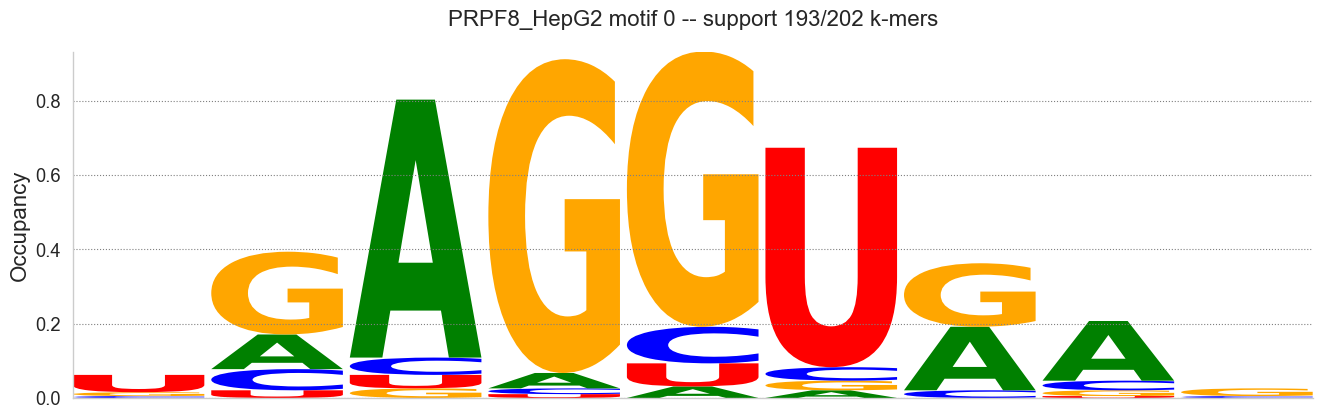

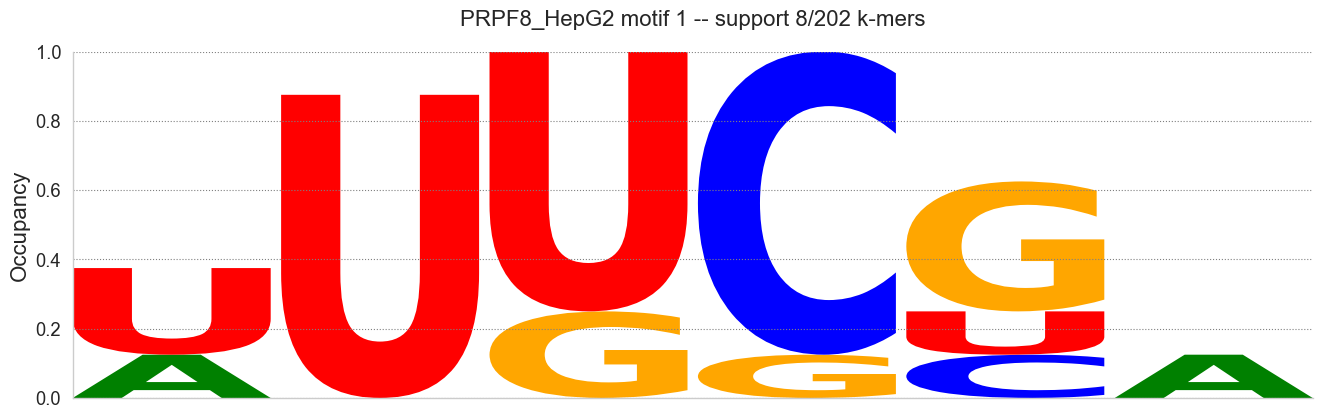

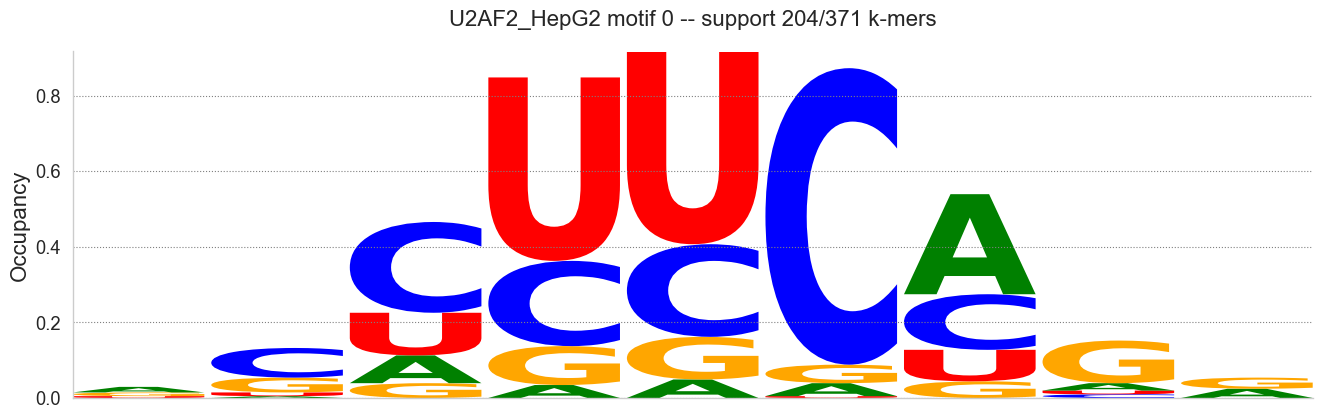

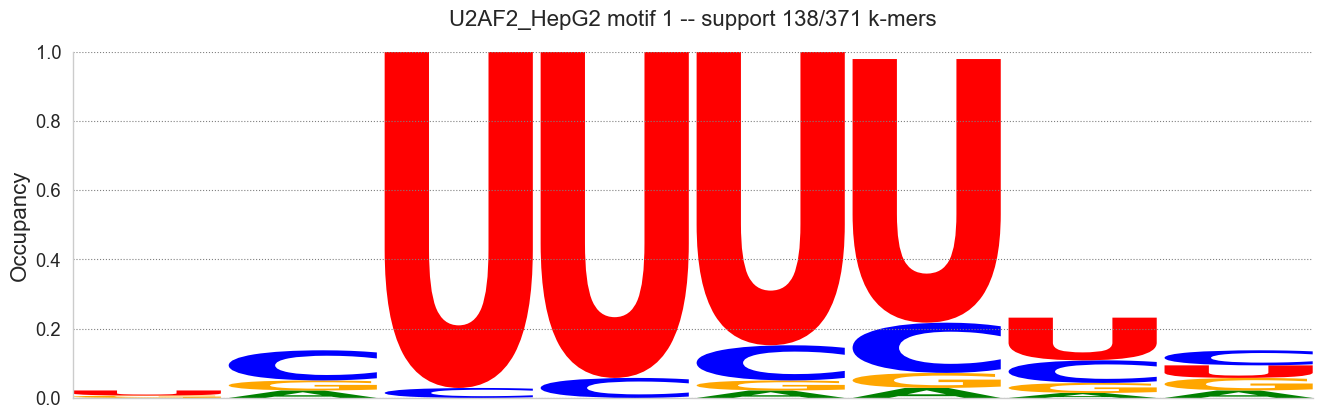

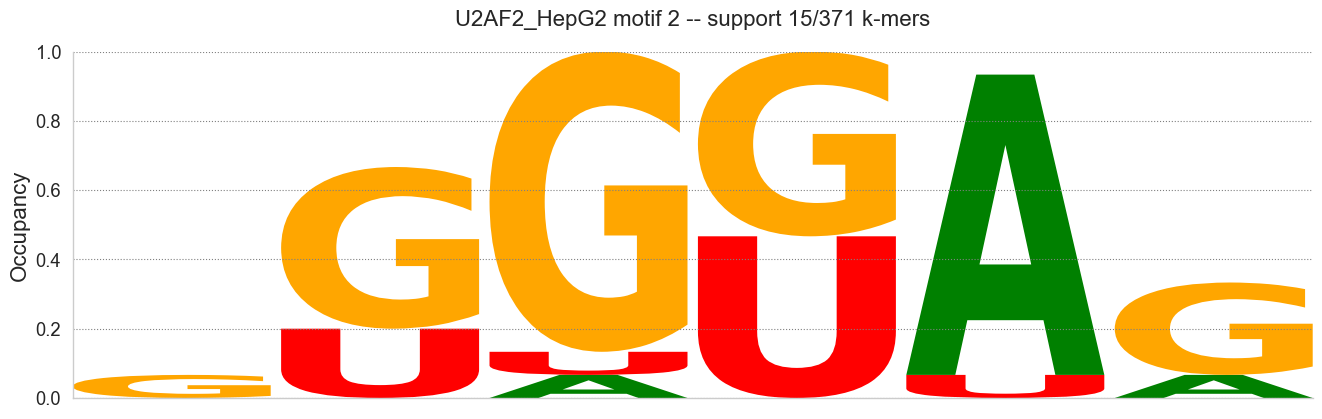

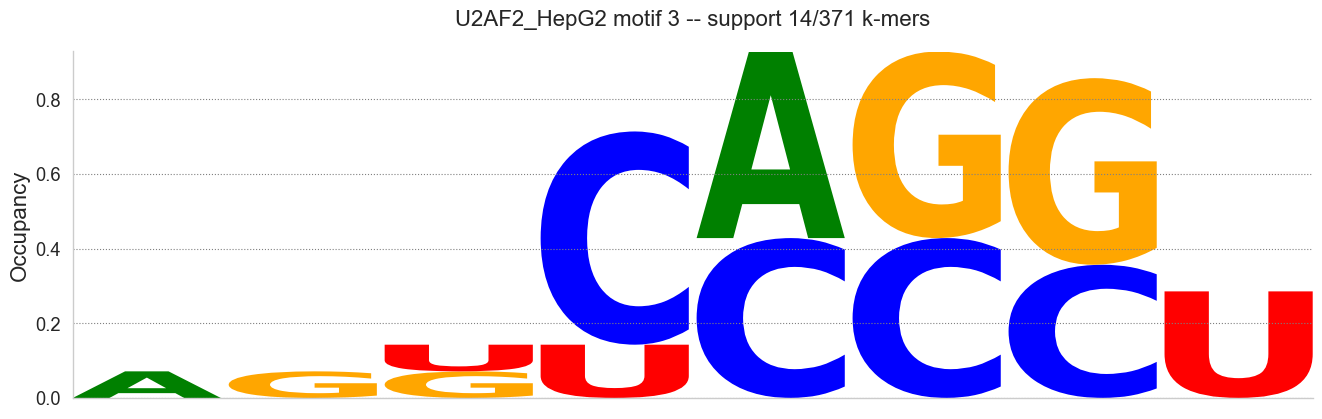

⏱ 0.63 s (00:00:00)


In [31]:
logging.getLogger("matplotlib.font_manager").setLevel(
    logging.ERROR
)  # silence missing-Arial findfont spam

for rbp_ct, motifs in motifs_by_rbp.items():
    out_dir = metamotif_paths[rbp_ct]["fasta"].parent
    if not motifs:
        logger.warning(f"{rbp_ct}: no motif clusters passed the support threshold.")
        continue

    for i, motif in enumerate(motifs):
        write_motif_tsv(
            motif.pwm,
            filepath=out_dir / f"motif-{i}.tsv",
            meta_info={"support": motif.support, "rbp_ct": rbp_ct},
        )
        # NOTE: metamotif.visualize.plot_motif references an undefined `axs` variable when called
        # with ax=... (upstream bug in metamotif/visualize.py) -- call it in its supported form
        # (no ax) so it builds and returns its own figure, matching how the upstream
        # scripts/seed-motif-alignment.py itself calls it.
        fig = plot_motif(
            motif.pwm,
            title=f"{rbp_ct} motif {i} -- support {motif.support}/{len(kmers_by_rbp[rbp_ct])} k-mers",
            ylab="Occupancy",
        )
        plt.show()
